# Comparison from OUT logs: `7m02` vs `oab5` vs `phmt` vs `d5g6`

This notebook parses training logs from:
- `Out/b_7m02_203816_train_0.out`
- `Out/b_oab5_203816_train_0.out`
- `Out/b_phmt_203816_train_0.out`
- `Out/b_d5g6_203816_train_0.out`

and compares:
- training loss progression
- VRAM usage
- training step running time


In [2]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

OUT_DIR = Path('Out')
SIM_FILES = {
    '7m02': OUT_DIR / 'b_7m02_203816_train_0.out',
    'oab5': OUT_DIR / 'b_oab5_203816_train_0.out',
    'phmt': OUT_DIR / 'b_phmt_203816_train_0.out',
    'd5g6': OUT_DIR / 'b_d5g6_203816_train_0.out',
    'jyqr': OUT_DIR / 'b_jyqr_203816_train_0.out',
}
# SIM_FILES = {
#     'jr9v': OUT_DIR / 'b_jr9v_203816_train_0.out',
#     'oab5': OUT_DIR / 'b_oab5_203816_train_0.out',
#     'vqfp': OUT_DIR / 'b_vqfp_203816_train_0.out',
#     'swzn': OUT_DIR / 'b_swzn_203816_train_0.out',
#     'hvw4': OUT_DIR / 'b_hvw4_203816_train_0.out',
#     'jyqr': OUT_DIR / 'b_jyqr_203816_train_0.out',
# }

sim_names = list(SIM_FILES.keys())
# sim_names = ['oab5', '2peq', 'txmj', 'h4yw', 'cg26', 'jr9v']
# sim_names = ['cg26', 'jr9v', '34qw', '62yr', '3nsu', '2u04']
# sim_names = ['bzgr', 'wv5m', 'y8to', 'f844', 'mq4j', 'c37g', 'ozty', '6e29', '1e7c', 'qla1', 'toy5']
# sim_names = ['lisk', 'skdi', 'b94d', 'cxuu']
# sim_names = ['zcg5', 'm1fk', 'rda5', 'nlgz', 'qsvm', 'z4zn', 'skdi', 'cxuu']
# voltage_dampening = [2., 5., 10., 20., 20., 20., 20., 2.]  # All simulations have the same voltage dampening
# voltage_dampening = np.arange(0.0, 1.1, 0.1)
voltage_dampening = [0.0, 0.1, 0.2, 0.3, 0.4]

if len(sim_names) != len(voltage_dampening):
    raise ValueError('sim_names and voltage_dampening must have the same length.')

sim_to_voltage_dampening = {name: float(d) for name, d in zip(sim_names, voltage_dampening)}
SIM_FILES = {
    f"dv={sim_to_voltage_dampening[name]:.1f} ({name})": OUT_DIR / f'b_{name}_203816_train_0.out'
    for name in sim_names
}
# SIM_FILES = {name: OUT_DIR / f'b_{name}_203816_train_0.out' for name in sim_names}

for sim_name, path in SIM_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f'Missing OUT file for {sim_name}: {path}')

SIM_FILES


{'dv=0.0 (7m02)': PosixPath('Out/b_7m02_203816_train_0.out'),
 'dv=0.1 (oab5)': PosixPath('Out/b_oab5_203816_train_0.out'),
 'dv=0.2 (phmt)': PosixPath('Out/b_phmt_203816_train_0.out'),
 'dv=0.3 (d5g6)': PosixPath('Out/b_d5g6_203816_train_0.out'),
 'dv=0.4 (jyqr)': PosixPath('Out/b_jyqr_203816_train_0.out')}

In [3]:
EPOCH_RE = re.compile(r'^Epoch\s+(\d+)/(\d+)')
STEP_RE = re.compile(r'^\s*Step\s+(\d+)/(\d+)')
LOSS_RE = re.compile(
    r'Loss\s+([0-9]+(?:\.[0-9]+)?),\s*'
    r'RLoss\s+([0-9]+(?:\.[0-9]+)?),\s*'
    r'VLoss\s+([0-9]+(?:\.[0-9]+)?),\s*'
    r'RegLoss\s+([0-9]+(?:\.[0-9]+)?),\s*'
    r'OLoss\s+([0-9]+(?:\.[0-9]+)?),\s*'
    r'SLoss\s+([0-9]+(?:\.[0-9]+)?),\s*'
    r'Rate\s+([0-9]+(?:\.[0-9]+)?)'
)
STEP_TIME_RE = re.compile(r'Step running time:\s*([0-9]+(?:\.[0-9]+)?)s')
TF_MEM_RE = re.compile(
    r'TensorFlow GPU 0 Memory Usage:\s*([0-9]+(?:\.[0-9]+)?)\s*GiB,\s*'
    r'Peak Usage:\s*([0-9]+(?:\.[0-9]+)?)\s*GiB'
)
TOTAL_MEM_RE = re.compile(
    r'Total GPU 0 Memory Usage:\s*Used:\s*([0-9]+(?:\.[0-9]+)?)\s*GiB,\s*'
    r'Free:\s*([0-9]+(?:\.[0-9]+)?)\s*GiB,\s*'
    r'Total:\s*([0-9]+(?:\.[0-9]+)?)\s*GiB'
)
TOTAL_TIME_RE = re.compile(r'Total time spent:\s*([0-9]+(?:\.[0-9]+)?)\s*seconds')
AVG_STEP_RE = re.compile(r'Average step time:\s*([0-9]+(?:\.[0-9]+)?)\s*seconds')


def parse_out_file(path: Path):
    rows = []
    metadata = {
        'path': str(path),
        'reported_total_time_s': np.nan,
        'reported_avg_step_time_s': np.nan,
    }

    current_epoch = None
    current = {}

    with path.open('r', encoding='utf-8', errors='replace') as f:
        for raw_line in f:
            line = raw_line.strip()

            m = TOTAL_TIME_RE.search(line)
            if m:
                metadata['reported_total_time_s'] = float(m.group(1))

            m = AVG_STEP_RE.search(line)
            if m:
                metadata['reported_avg_step_time_s'] = float(m.group(1))

            m = EPOCH_RE.match(line)
            if m:
                current_epoch = int(m.group(1))
                continue

            m = STEP_RE.match(line)
            if m:
                current = {
                    'epoch': current_epoch,
                    'step_in_epoch': int(m.group(1)),
                }
                continue

            m = LOSS_RE.search(line)
            if m and current:
                (
                    current['loss'],
                    current['rate_loss'],
                    current['voltage_loss'],
                    current['regularizer_loss'],
                    current['osi_dsi_loss'],
                    current['sync_loss'],
                    current['firing_rate'],
                ) = [float(x) for x in m.groups()]
                continue

            m = STEP_TIME_RE.search(line)
            if m and current:
                current['step_time_s'] = float(m.group(1))
                continue

            m = TF_MEM_RE.search(line)
            if m and current:
                current['tf_mem_gib'] = float(m.group(1))
                current['tf_peak_gib'] = float(m.group(2))
                continue

            m = TOTAL_MEM_RE.search(line)
            if m and current:
                current['gpu_used_gib'] = float(m.group(1))
                current['gpu_free_gib'] = float(m.group(2))
                current['gpu_total_gib'] = float(m.group(3))

                required = [
                    'epoch', 'step_in_epoch', 'loss', 'rate_loss', 'voltage_loss',
                    'regularizer_loss', 'osi_dsi_loss', 'sync_loss', 'firing_rate',
                    'step_time_s', 'tf_mem_gib', 'tf_peak_gib',
                    'gpu_used_gib', 'gpu_free_gib', 'gpu_total_gib',
                ]
                if all(k in current for k in required):
                    rows.append(current.copy())
                current = {}

    for idx, row in enumerate(rows, start=1):
        row['global_step'] = idx

    return rows, metadata


def moving_average(arr, window=50):
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0:
        return arr
    out = np.empty_like(arr)
    csum = np.cumsum(arr)
    for i in range(arr.size):
        start = max(0, i - window + 1)
        count = i - start + 1
        total = csum[i] - (csum[start - 1] if start > 0 else 0.0)
        out[i] = total / count
    return out


def col(rows, key):
    return np.asarray([r[key] for r in rows], dtype=float)


In [4]:
data_by_sim = {}
meta_by_sim = {}

for sim_name, out_path in SIM_FILES.items():
    rows, meta = parse_out_file(out_path)
    data_by_sim[sim_name] = rows
    meta_by_sim[sim_name] = meta

for sim_name in sorted(data_by_sim):
    rows = data_by_sim[sim_name]
    epochs = sorted(set(int(r['epoch']) for r in rows))
    print(
        f"{sim_name}: steps={len(rows)}, epochs={len(epochs)} "
        f"(min={epochs[0] if epochs else 'n/a'}, max={epochs[-1] if epochs else 'n/a'})"
    )

print('Metadata:')
for sim_name in sorted(meta_by_sim):
    print(sim_name, meta_by_sim[sim_name])


dv=0.0 (7m02): steps=2500, epochs=25 (min=1, max=25)
dv=0.1 (oab5): steps=2500, epochs=25 (min=1, max=25)
dv=0.2 (phmt): steps=1000, epochs=10 (min=1, max=10)
dv=0.3 (d5g6): steps=1798, epochs=18 (min=1, max=18)
dv=0.4 (jyqr): steps=2500, epochs=25 (min=1, max=25)
Metadata:
dv=0.0 (7m02) {'path': 'Out/b_7m02_203816_train_0.out', 'reported_total_time_s': 41663.54, 'reported_avg_step_time_s': 16.27}
dv=0.1 (oab5) {'path': 'Out/b_oab5_203816_train_0.out', 'reported_total_time_s': 41445.06, 'reported_avg_step_time_s': 16.12}
dv=0.2 (phmt) {'path': 'Out/b_phmt_203816_train_0.out', 'reported_total_time_s': 15788.32, 'reported_avg_step_time_s': 15.27}
dv=0.3 (d5g6) {'path': 'Out/b_d5g6_203816_train_0.out', 'reported_total_time_s': nan, 'reported_avg_step_time_s': nan}
dv=0.4 (jyqr) {'path': 'Out/b_jyqr_203816_train_0.out', 'reported_total_time_s': 42273.67, 'reported_avg_step_time_s': 16.56}


In [5]:
summary_rows = []
for sim_name in sorted(data_by_sim):
    rows = data_by_sim[sim_name]
    loss = col(rows, 'loss')
    step_time = col(rows, 'step_time_s')
    tf_mem = col(rows, 'tf_mem_gib')
    tf_peak = col(rows, 'tf_peak_gib')
    gpu_used = col(rows, 'gpu_used_gib')
    epochs = np.asarray([int(r['epoch']) for r in rows], dtype=int)

    summary_rows.append({
        'sim_name': sim_name,
        'steps': int(len(rows)),
        'epochs': int(len(np.unique(epochs))),
        'initial_loss': float(loss[0]),
        'final_loss': float(loss[-1]),
        'min_loss': float(np.min(loss)),
        'step_time_mean_s': float(np.mean(step_time)),
        'step_time_median_s': float(np.median(step_time)),
        'step_time_std_s': float(np.std(step_time, ddof=1)),
        'tf_mem_max_gib': float(np.max(tf_mem)),
        'tf_peak_max_gib': float(np.max(tf_peak)),
        'gpu_used_max_gib': float(np.max(gpu_used)),
        'reported_total_time_s': float(meta_by_sim[sim_name]['reported_total_time_s']),
        'reported_avg_step_time_s': float(meta_by_sim[sim_name]['reported_avg_step_time_s']),
    })

summary_rows


[{'sim_name': 'dv=0.0 (7m02)',
  'steps': 2500,
  'epochs': 25,
  'initial_loss': 8.1128,
  'final_loss': 0.247,
  'min_loss': 0.1987,
  'step_time_mean_s': 16.334284000000004,
  'step_time_median_s': 16.76,
  'step_time_std_s': 1.3078832634437672,
  'tf_mem_max_gib': 7.33,
  'tf_peak_max_gib': 79.8,
  'gpu_used_max_gib': 82.33,
  'reported_total_time_s': 41663.54,
  'reported_avg_step_time_s': 16.27},
 {'sim_name': 'dv=0.1 (oab5)',
  'steps': 2500,
  'epochs': 25,
  'initial_loss': 8.1249,
  'final_loss': 0.2374,
  'min_loss': 0.2008,
  'step_time_mean_s': 16.195111999999998,
  'step_time_median_s': 16.68,
  'step_time_std_s': 1.3802608432662942,
  'tf_mem_max_gib': 7.33,
  'tf_peak_max_gib': 76.74,
  'gpu_used_max_gib': 80.93,
  'reported_total_time_s': 41445.06,
  'reported_avg_step_time_s': 16.12},
 {'sim_name': 'dv=0.2 (phmt)',
  'steps': 1000,
  'epochs': 10,
  'initial_loss': 8.1073,
  'final_loss': 0.5238,
  'min_loss': 0.5238,
  'step_time_mean_s': 15.33137,
  'step_time_media

## Training loss progression

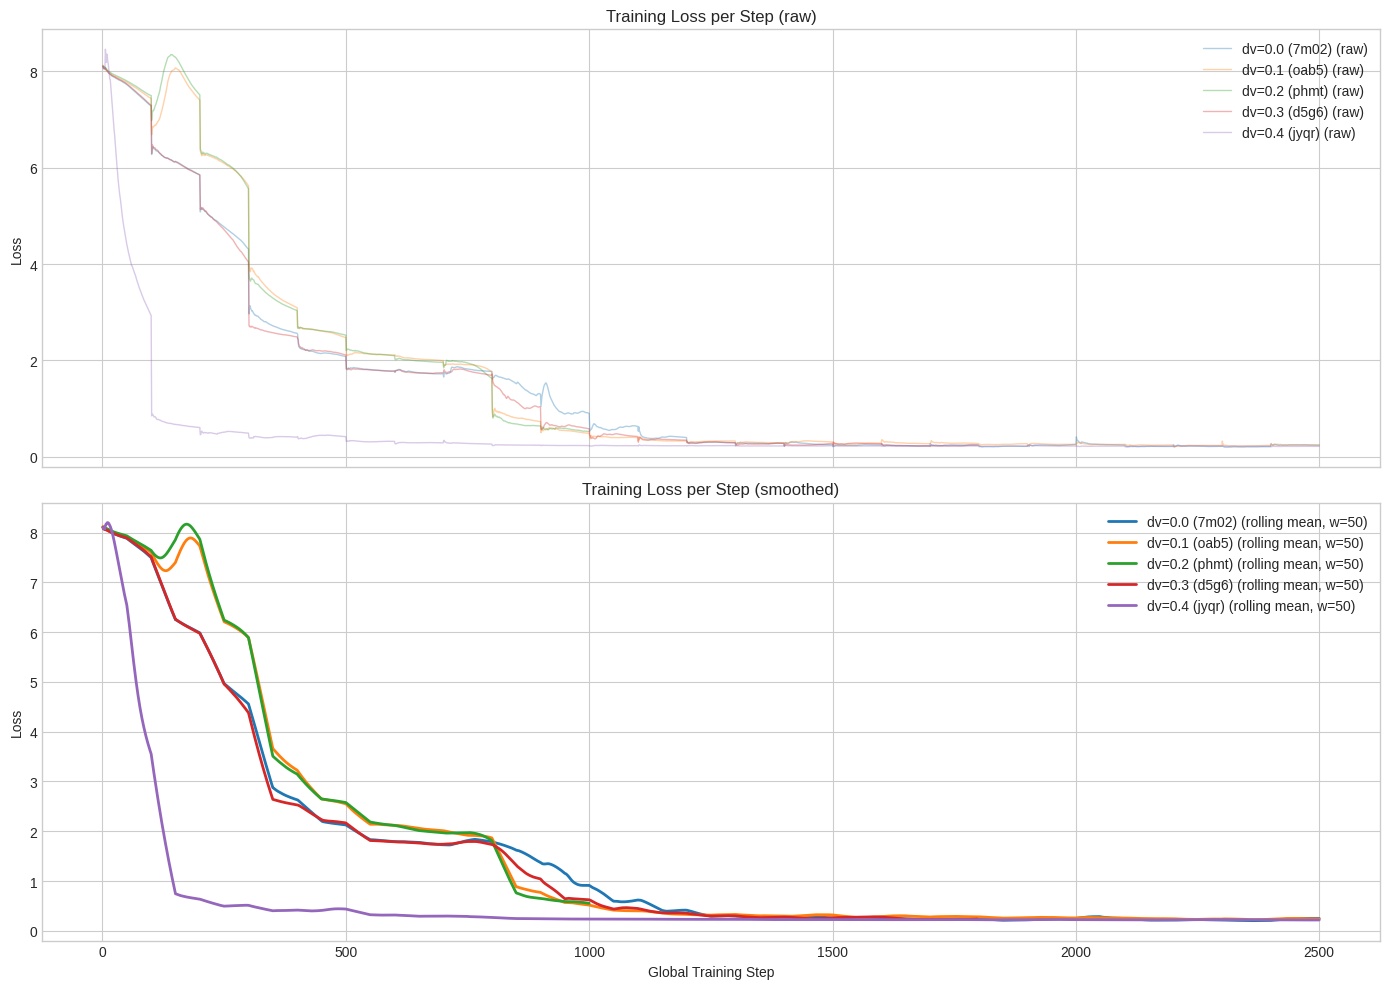

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for sim_name in sorted(data_by_sim):
    rows = data_by_sim[sim_name]
    x = col(rows, 'global_step')
    y = col(rows, 'loss')

    axes[0].plot(x, y, alpha=0.35, linewidth=1.0, label=f'{sim_name} (raw)')
    axes[1].plot(x, moving_average(y, window=50), linewidth=2.0, label=f'{sim_name} (rolling mean, w=50)')

axes[0].set_title('Training Loss per Step (raw)')
axes[0].set_ylabel('Loss')
# axes[0].set_ylim(bottom=0.2, top=5)
# axes[0].set_xlim(0, 1000)
axes[0].legend()

axes[1].set_title('Training Loss per Step (smoothed)')
axes[1].set_xlabel('Global Training Step')
axes[1].set_ylabel('Loss')
# axes[1].set_ylim(bottom=0.2, top=5)
# axes[1].set_xlim(0, 1000)
axes[1].legend()

plt.tight_layout()
plt.show()


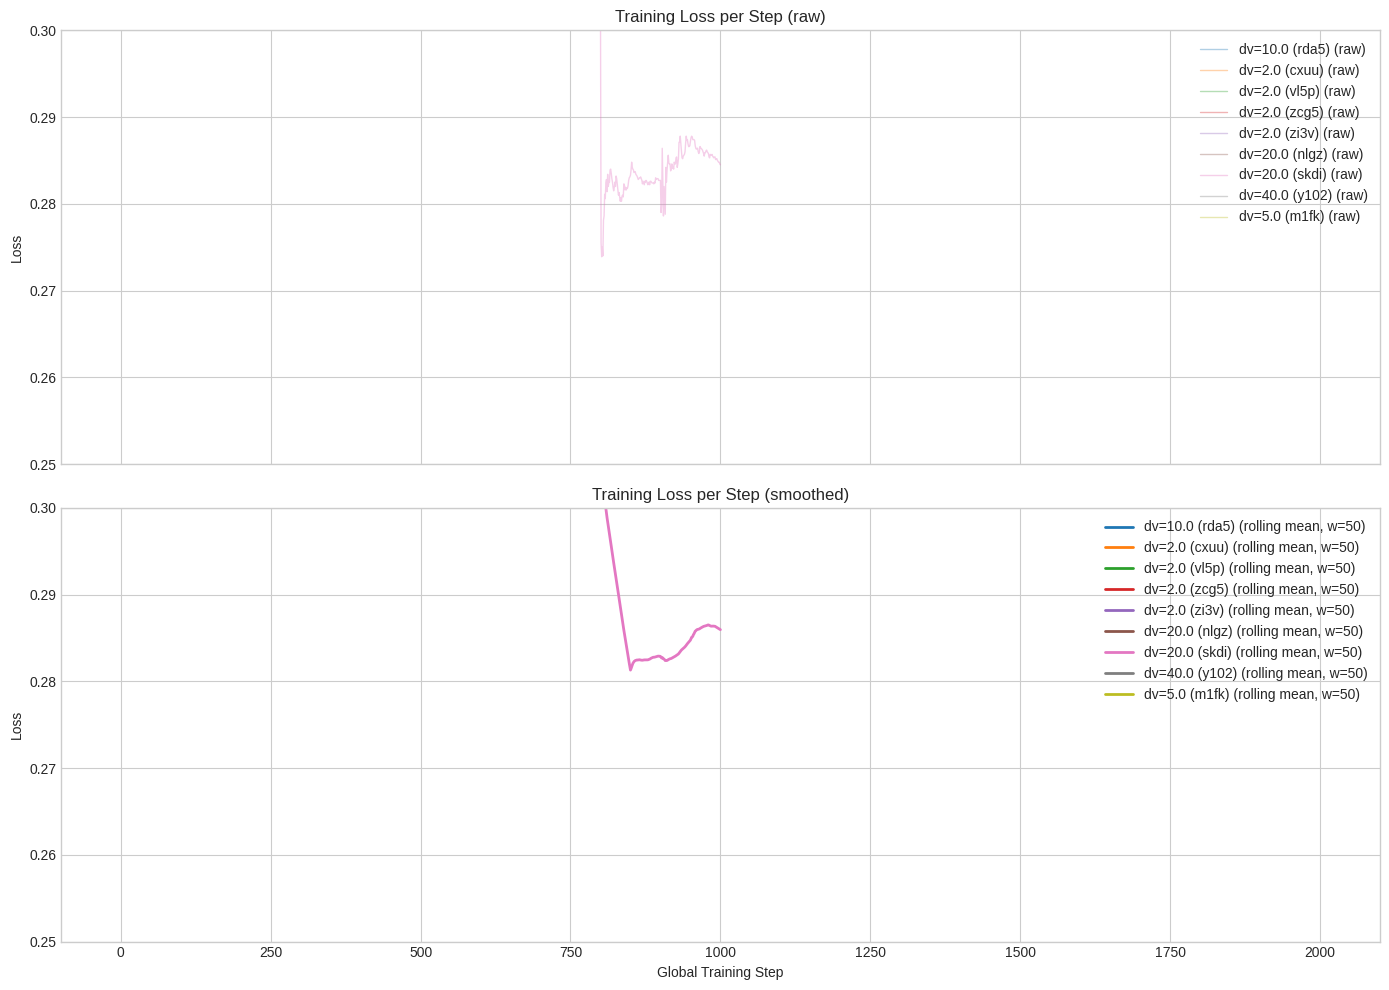

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for sim_name in sorted(data_by_sim):
    rows = data_by_sim[sim_name]
    x = col(rows, 'global_step')
    y = col(rows, 'loss')

    axes[0].plot(x, y, alpha=0.35, linewidth=1.0, label=f'{sim_name} (raw)')
    axes[1].plot(x, moving_average(y, window=50), linewidth=2.0, label=f'{sim_name} (rolling mean, w=50)')

axes[0].set_title('Training Loss per Step (raw)')
axes[0].set_ylabel('Loss')
# axes[0].set_ylim(bottom=0.2, top=0.5)
axes[0].set_ylim(bottom=0.25, top=0.30)
axes[0].legend()

axes[1].set_title('Training Loss per Step (smoothed)')
axes[1].set_xlabel('Global Training Step')
axes[1].set_ylabel('Loss')
axes[1].set_ylim(bottom=0.25, top=0.30)
axes[1].legend()

plt.tight_layout()
plt.show()


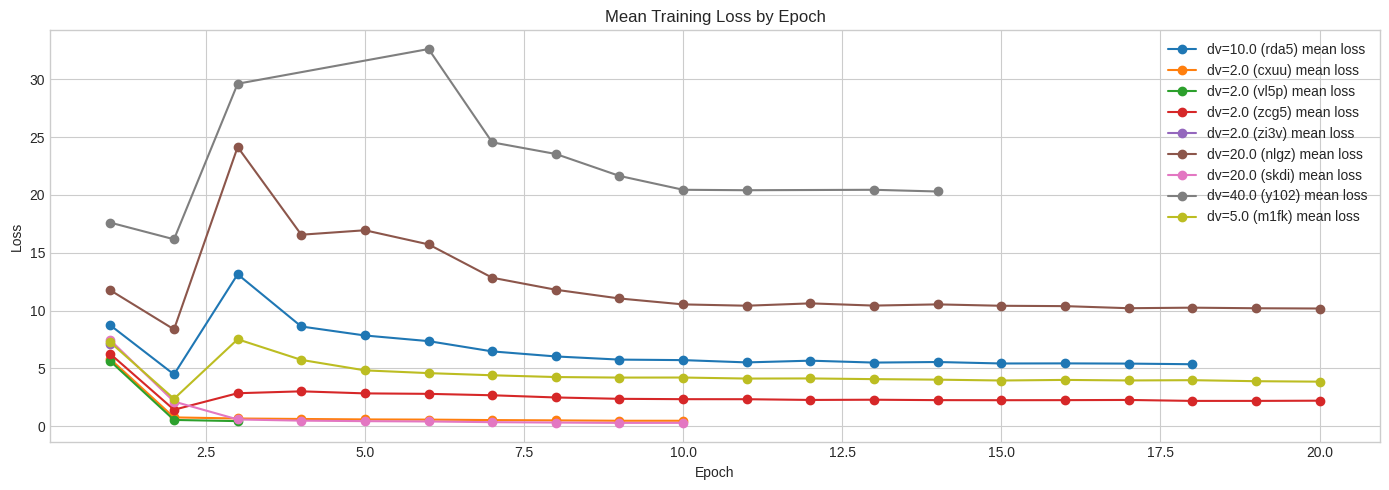

In [ ]:
fig, ax = plt.subplots(figsize=(14, 5))

for sim_name in sorted(data_by_sim):
    rows = data_by_sim[sim_name]
    epochs = np.asarray([int(r['epoch']) for r in rows], dtype=int)
    losses = col(rows, 'loss')

    unique_epochs = np.unique(epochs)
    epoch_means = np.array([np.mean(losses[epochs == ep]) for ep in unique_epochs])

    ax.plot(unique_epochs, epoch_means, marker='o', label=f'{sim_name} mean loss')

ax.set_title('Mean Training Loss by Epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()


## Loss components evolution panel


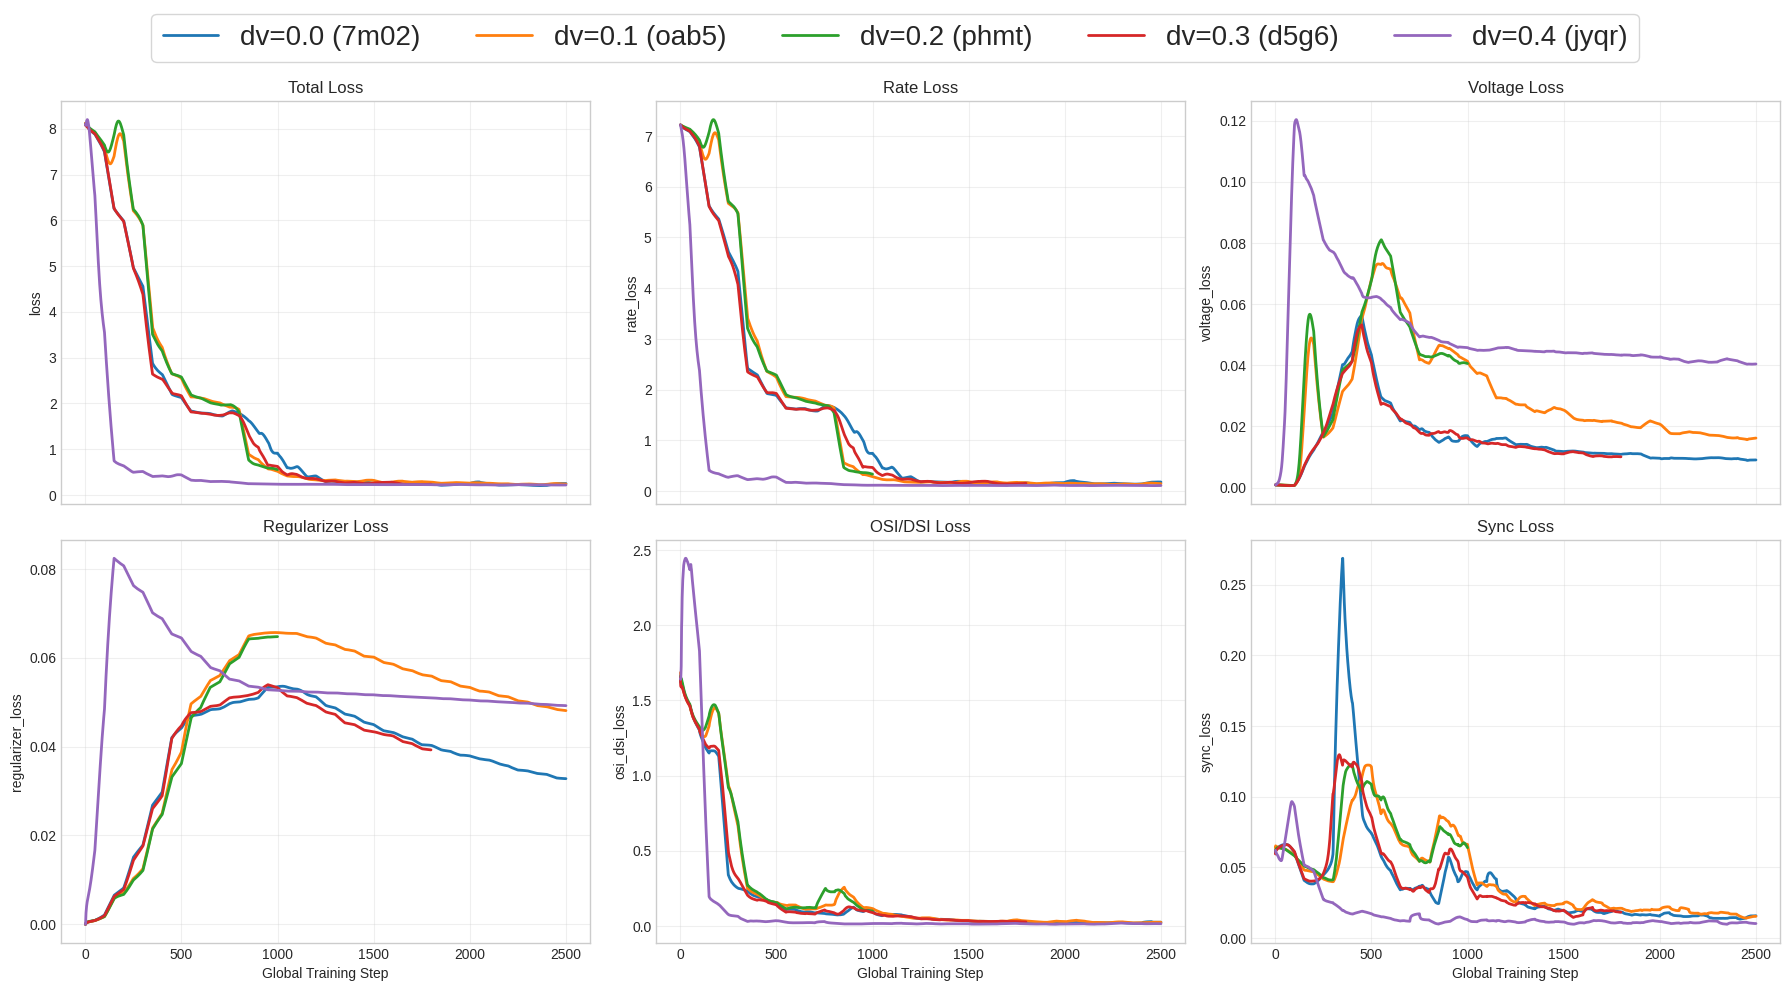

In [7]:
loss_components = [
    ('loss', 'Total Loss'),
    ('rate_loss', 'Rate Loss'),
    ('voltage_loss', 'Voltage Loss'),
    ('regularizer_loss', 'Regularizer Loss'),
    ('osi_dsi_loss', 'OSI/DSI Loss'),
    ('sync_loss', 'Sync Loss'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
axes = axes.ravel()

for ax, (metric_key, title) in zip(axes, loss_components):
    for sim_name in sorted(data_by_sim):
        rows = data_by_sim[sim_name]
        x = col(rows, 'global_step')
        y = col(rows, metric_key)
        ax.plot(x, moving_average(y, window=50), linewidth=2.0, label=sim_name)

    ax.set_title(title)
    ax.set_ylabel(metric_key)
    ax.grid(alpha=0.3)
    # ax.set_xlim(0, 1000)

for ax in axes[3:]:
    ax.set_xlabel('Global Training Step')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(sorted(data_by_sim)), frameon=True, fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## Step time comparison

/tmp/ipykernel_896310/2477547880.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(box_data, labels=labels, showfliers=False)


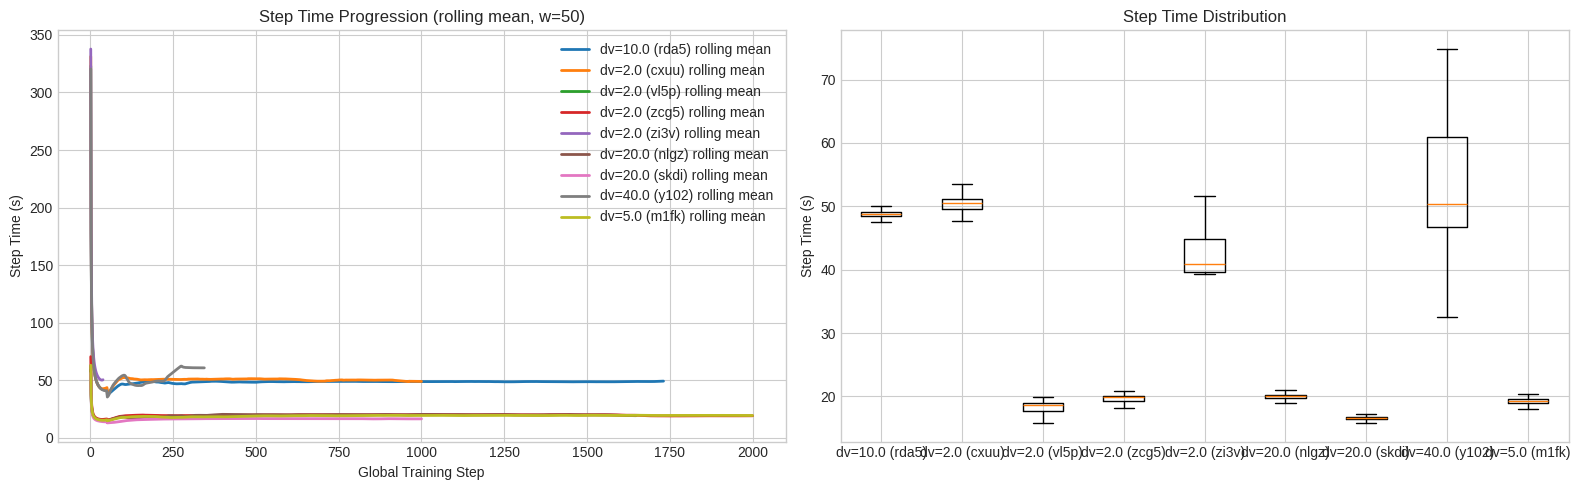

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels = []
box_data = []
for sim_name in sorted(data_by_sim):
    rows = data_by_sim[sim_name]
    x = col(rows, 'global_step')
    step_time = col(rows, 'step_time_s')

    axes[0].plot(x, moving_average(step_time, window=50), linewidth=2, label=f'{sim_name} rolling mean')

    labels.append(sim_name)
    box_data.append(step_time)

axes[0].set_title('Step Time Progression (rolling mean, w=50)')
axes[0].set_xlabel('Global Training Step')
axes[0].set_ylabel('Step Time (s)')
axes[0].legend()

axes[1].boxplot(box_data, labels=labels, showfliers=False)
axes[1].set_title('Step Time Distribution')
axes[1].set_ylabel('Step Time (s)')

plt.tight_layout()
plt.show()


## VRAM comparison

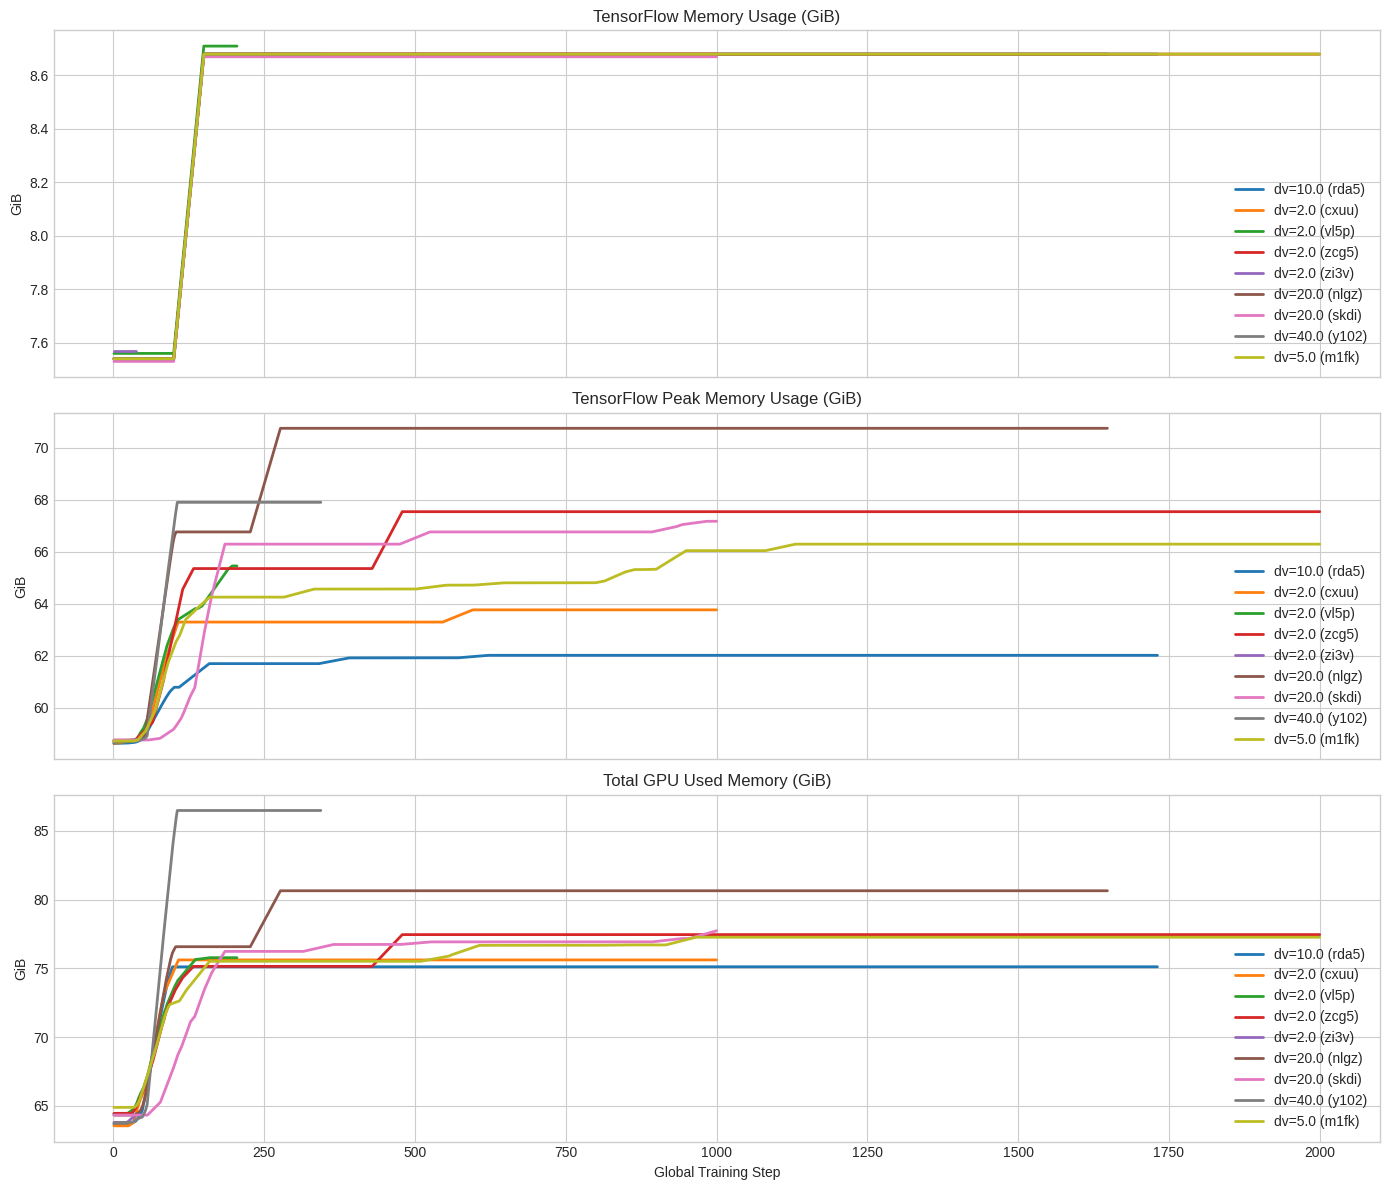

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

metrics = [
    ('tf_mem_gib', 'TensorFlow Memory Usage (GiB)'),
    ('tf_peak_gib', 'TensorFlow Peak Memory Usage (GiB)'),
    ('gpu_used_gib', 'Total GPU Used Memory (GiB)'),
]

for idx, (metric, title) in enumerate(metrics):
    ax = axes[idx]
    for sim_name in sorted(data_by_sim):
        rows = data_by_sim[sim_name]
        x = col(rows, 'global_step')
        y = col(rows, metric)
        ax.plot(x, moving_average(y, window=50), linewidth=2, label=sim_name)

    ax.set_title(title)
    ax.set_ylabel('GiB')
    ax.legend()

axes[-1].set_xlabel('Global Training Step')
plt.tight_layout()
plt.show()


## Quick delta view (each sim - lowest dampening reference)

In [ ]:
by_name = {row['sim_name']: row for row in summary_rows}

reference = next((name for name in by_name if name.startswith('dv=0.0')), None)
if reference is None and by_name:
    reference = sorted(by_name)[0]
common_keys = [
    'steps', 'epochs', 'initial_loss', 'final_loss', 'min_loss',
    'step_time_mean_s', 'step_time_median_s', 'step_time_std_s',
    'tf_mem_max_gib', 'tf_peak_max_gib', 'gpu_used_max_gib',
    'reported_total_time_s', 'reported_avg_step_time_s',
]

if reference is not None and reference in by_name:
    ref = by_name[reference]
    deltas = {}
    for sim_name in sorted(by_name):
        if sim_name == reference:
            continue
        target = by_name[sim_name]
        deltas[f'{sim_name} - {reference}'] = {
            k: float(target[k] - ref[k]) for k in common_keys
        }
    deltas
else:
    print('No reference simulation available in summary_rows.')
